# Practical 1 — Generative AI vs Discriminative Models

**Aim:** To study Generative AI and compare generative and discriminative models using the handwritten digit dataset.

### Concepts
- Discriminative models learn how to distinguish between classes.
- Generative models learn the distribution of data and can be used to generate new samples.
- The `load_digits` dataset is used as a small MNIST-like dataset available directly through scikit-learn.

### Expected result
A discriminative classifier predicts digit labels, while a simple generative model learns class-wise pixel distributions and generates synthetic digit-like samples.


In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)


In [2]:
# Load the handwritten digit dataset
digits = load_digits()

X = digits.data          # flattened 8x8 images
y = digits.target
images = digits.images

print("Number of samples:", len(X))
print("Image shape:", images[0].shape)
print("Number of classes:", len(np.unique(y)))


Number of samples: 1797
Image shape: (8, 8)
Number of classes: 10


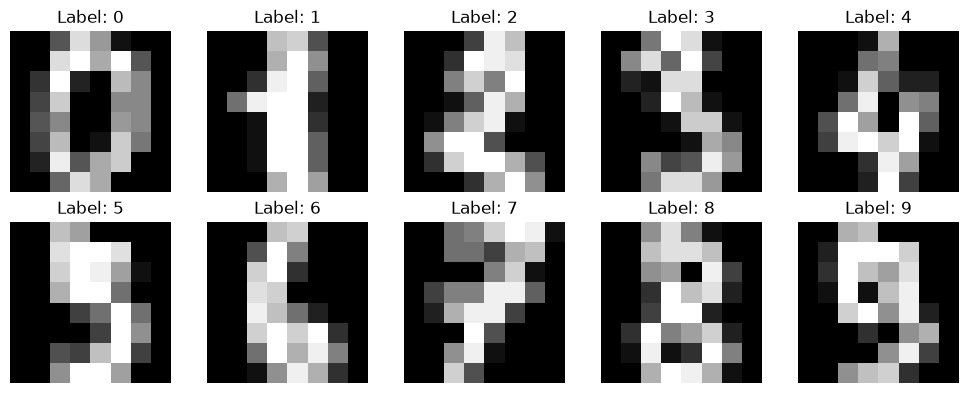

In [3]:
# Display sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, label in zip(axes.ravel(), images[:10], y[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 1. Discriminative Model

A discriminative model learns a decision boundary between classes.

Here, Logistic Regression learns:

\[
P(y|x)
\]

and predicts the digit class for an input image.


In [4]:
# Train a discriminative model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

discriminative_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

discriminative_model.fit(X_train, y_train)

y_pred = discriminative_model.predict(X_test)

print("Discriminative Model Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Discriminative Model Accuracy: 0.9583333333333334

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.89      0.89      0.89        36
           2       0.97      1.00      0.99        35
           3       0.95      1.00      0.97        37
           4       0.95      1.00      0.97        36
           5       0.97      0.97      0.97        37
           6       1.00      0.97      0.99        36
           7       1.00      0.97      0.99        36
           8       0.86      0.86      0.86        35
           9       1.00      0.94      0.97        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



## 2. Generative Model

A simple generative approach is Gaussian Naive Bayes.

For each class, it models the probability distribution of the features:

\[
P(x|y)
\]

and combines it with the class probability to predict:

\[
P(y|x)
\]

Because it models the input distribution, it can also be used to sample synthetic feature vectors.


In [5]:
# Train a simple generative model
generative_model = GaussianNB()
generative_model.fit(X_train, y_train)

y_pred_gen = generative_model.predict(X_test)

print("Generative Model Accuracy:",
      accuracy_score(y_test, y_pred_gen))


Generative Model Accuracy: 0.8111111111111111


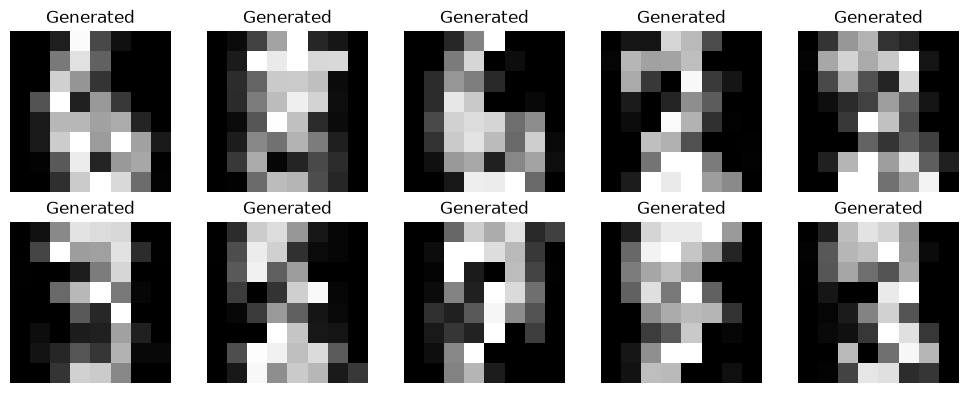

In [6]:
# Generate synthetic digit-like samples from the Gaussian model
n_samples = 10

generated = []

for _ in range(n_samples):
    # Randomly select a digit class
    digit_class = np.random.randint(0, 10)

    # GaussianNB stores mean and variance for every class/feature
    mean = generative_model.theta_[digit_class]
    variance = generative_model.var_[digit_class]

    sample = np.random.normal(
        loc=mean,
        scale=np.sqrt(variance + 1e-6)
    )

    sample = np.clip(sample, 0, 16)
    generated.append(sample.reshape(8, 8))

generated = np.array(generated)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(generated[i], cmap="gray")
    ax.set_title("Generated")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Comparison

| Aspect | Discriminative | Generative |
|---|---|---|
| Main purpose | Classification / prediction | Model data distribution / generation |
| Typical learning | \(P(y|x)\) | \(P(x|y)\) and related distributions |
| Example | Logistic Regression | Gaussian Naive Bayes |
| Can generate samples? | Usually no | Yes, if the model supports sampling |
| Main focus | Decision boundary | Data distribution |

### Conclusion
Discriminative models focus on separating classes, whereas generative models attempt to model how the data is distributed and can therefore be used to create synthetic samples.
